<a href="https://colab.research.google.com/github/Parthwadekar40/ParthCM40-Pattern-Recognition/blob/main/Practical_1_PR_Parth40.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import euclidean_distances, manhattan_distances, cosine_similarity
!pip install python-Levenshtein
import Levenshtein
np.random.seed(42)
numerical_features = np.array([
    [1200, 15, 4.8],
    [1150, 14, 4.7],
    [200,  2,  3.5],
    [600,  6,  4.2],
    [1300, 3,  4.9]
])
purchase_sequences = [
    "Electronics > Accessories > Clothing",
    "Electronics > Accessories > Clothing",
    "Home > Groceries",
    "Electronics > Home > Clothing",
    "Electronics > Accessories"
]
customer_ids = [f"Customer_{i}" for i in range(len(numerical_features))]
scaler = MinMaxScaler()
normalized_features = scaler.fit_transform(numerical_features)
print("--- Normalized Feature Matrix ---")
df_norm = pd.DataFrame(normalized_features, columns=["Spend", "Freq", "Rating"], index=customer_ids)
print(df_norm.round(3))
print("\n" + "="*50 + "\n")
euclidean_matrix = euclidean_distances(normalized_features)
manhattan_matrix = manhattan_distances(normalized_features)
cosine_matrix = cosine_similarity(normalized_features)
n_customers = len(customer_ids)
edit_distance_matrix = np.zeros((n_customers, n_customers))
for i in range(n_customers):
    for j in range(n_customers):
        edit_distance_matrix[i, j] = Levenshtein.distance(purchase_sequences[i], purchase_sequences[j])
df_euclidean = pd.DataFrame(euclidean_matrix, columns=customer_ids, index=customer_ids)
df_manhattan = pd.DataFrame(manhattan_matrix, columns=customer_ids, index=customer_ids)
df_cosine = pd.DataFrame(cosine_matrix, columns=customer_ids, index=customer_ids)
df_edit = pd.DataFrame(edit_distance_matrix, columns=customer_ids, index=customer_ids)
print("1. EUCLIDEAN DISTANCE MATRIX (Lower is closer)")
print(df_euclidean.round(3))
print("\n2. MANHATTAN DISTANCE MATRIX (Lower is closer)")
print(df_manhattan.round(3))
print("\n3. COSINE SIMILARITY MATRIX (Higher is closer; 1.0 is perfect)")
print(df_cosine.round(3))
print("\n4. EDIT DISTANCE MATRIX (Fewer string edits = more similar sequence)")
print(df_edit.astype(int))
print("\n" + "="*50 + "\n")
print("--- INSIGHTS & RECOMMENDATION ALIGNMENT ---")
c0_euclidean_scores = df_euclidean.loc["Customer_0"].drop("Customer_0")
most_similar_numerical = c0_euclidean_scores.idxmin()
min_distance = c0_euclidean_scores.min()
c0_edit_scores = df_edit.loc["Customer_0"].drop("Customer_0")
most_similar_sequence = c0_edit_scores.idxmin()
min_edit = c0_edit_scores.min()
print(f"Target Focus: Customer_0 Profile")
print(f" -> Numerical Companion: {most_similar_numerical} (Euclidean Distance: {min_distance:.3f})")
print(f" -> Sequential Companion: {most_similar_sequence} (Edit Distance: {int(min_edit)} modifications)")
print(f"\n[Strategy Action]: Recommend items bought by {most_similar_numerical} to Customer_0.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 44.5 MB/s eta 0:00:00
--- Normalized Feature Matrix ---
            Spend   Freq  Rating
Customer_0  0.909  1.000   0.929
Customer_1  0.864  0.923   0.857
Customer_2  0.000  0.000   0.000
Customer_3  0.364  0.308   0.500
Customer_4  1.000  0.077   1.000


1. EUCLIDEAN DISTANCE MATRIX (Lower is closer)
            Customer_0  Customer_1  Customer_2  Customer_3  Customer_4
Customer_0       0.000       0.114       1.640       0.980       0.930
Customer_1       0.114       0.000       1.527       0.870       0.869
Customer_2       1.640       1.527       0.000       0.691       1.416
Customer_3       0.980       0.870       0.691       0.000       0.842
Customer_4       0.930       0.869       1.416       0.842       0.000

2. MANHATTAN DISTANCE MATRIX (Lower is closer)
            Customer_0  Customer_1  Customer_2  Customer_3  Customer_4
Customer_0       

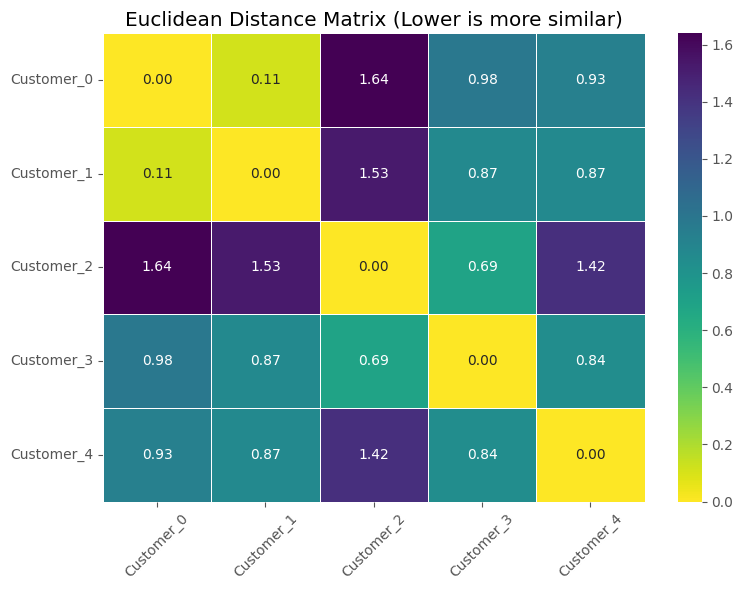

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_euclidean, annot=True, cmap='viridis_r', fmt=".2f", linewidths=.5, ax=ax)
ax.set_title('Euclidean Distance Matrix (Lower is more similar)')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

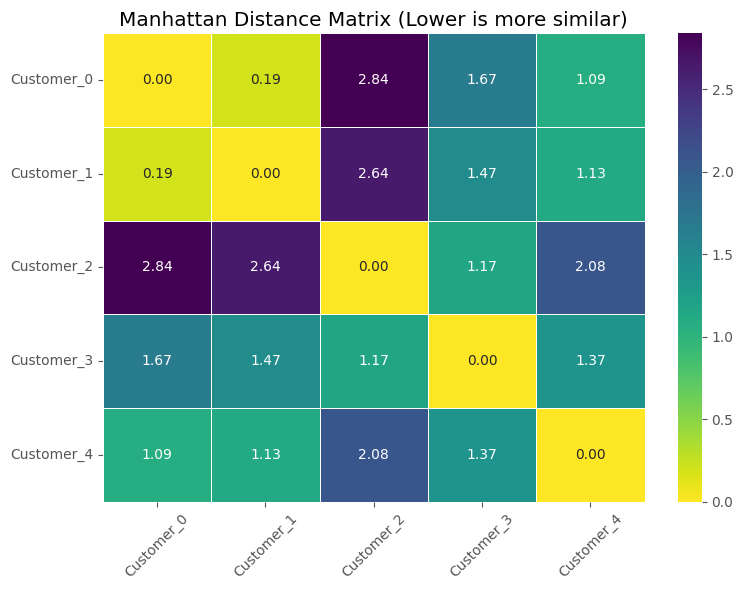

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_manhattan, annot=True, cmap='viridis_r', fmt=".2f", linewidths=.5, ax=ax)
ax.set_title('Manhattan Distance Matrix (Lower is more similar)')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

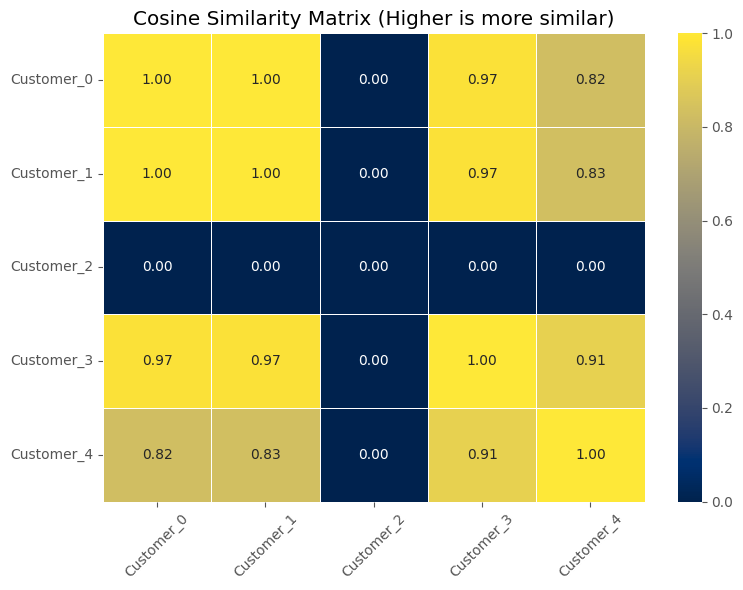

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_cosine, annot=True, cmap='cividis', fmt=".2f", linewidths=.5, ax=ax)
ax.set_title('Cosine Similarity Matrix (Higher is more similar)')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

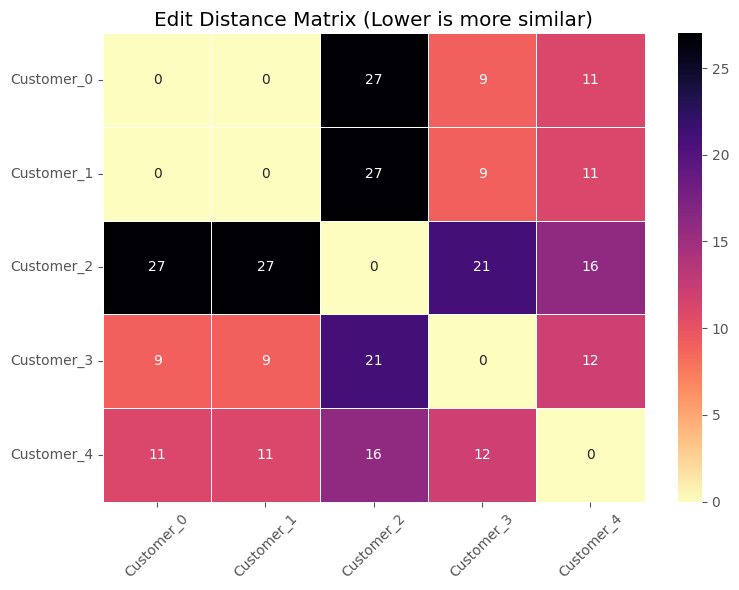

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_edit, annot=True, cmap='magma_r', fmt=".0f", linewidths=.5, ax=ax)
ax.set_title('Edit Distance Matrix (Lower is more similar)')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

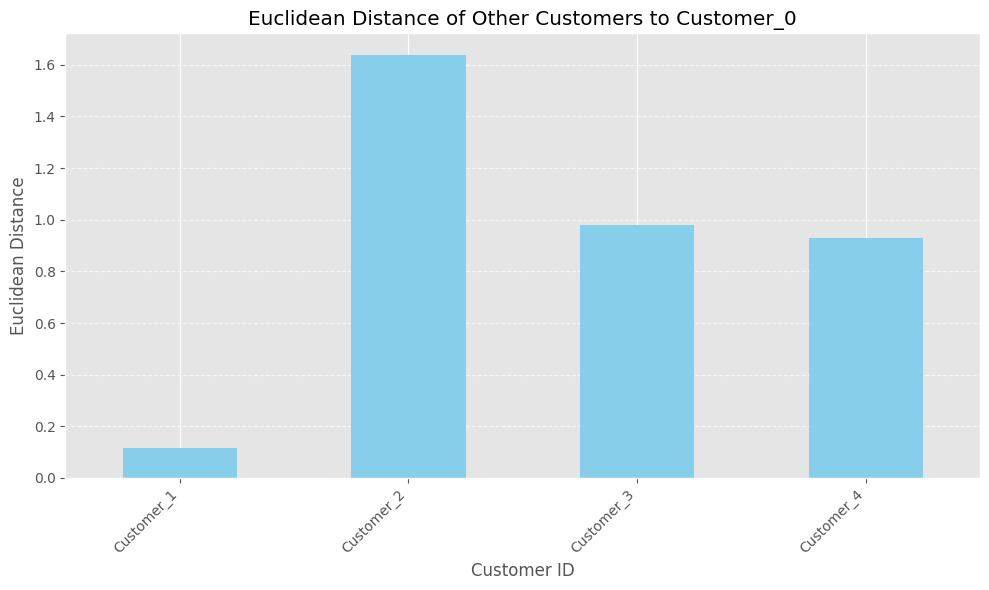

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
c0_euclidean_scores.plot(kind='bar', ax=ax, color='skyblue')
ax.set_title('Euclidean Distance of Other Customers to Customer_0')
ax.set_xlabel('Customer ID')
ax.set_ylabel('Euclidean Distance')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

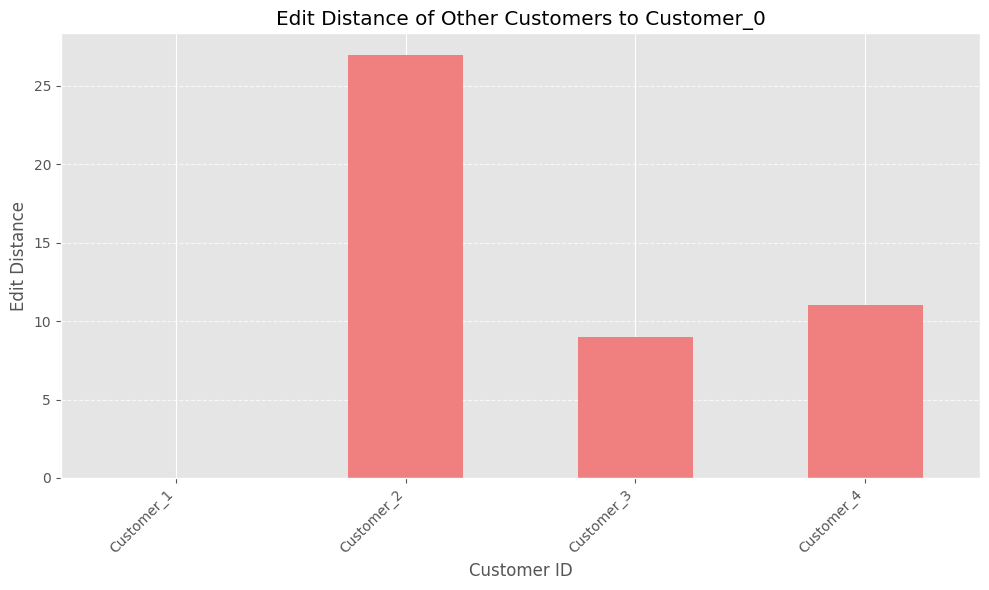

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
c0_edit_scores.plot(kind='bar', ax=ax, color='lightcoral')
ax.set_title('Edit Distance of Other Customers to Customer_0')
ax.set_xlabel('Customer ID')
ax.set_ylabel('Edit Distance')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()